In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/creditcard.csv")

/tmp/ipykernel_458/3469698040.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/creditcard.csv")


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop("Class", axis=1)
y = df["Class"]

X = X.replace('-', np.nan)
X = X.dropna()
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

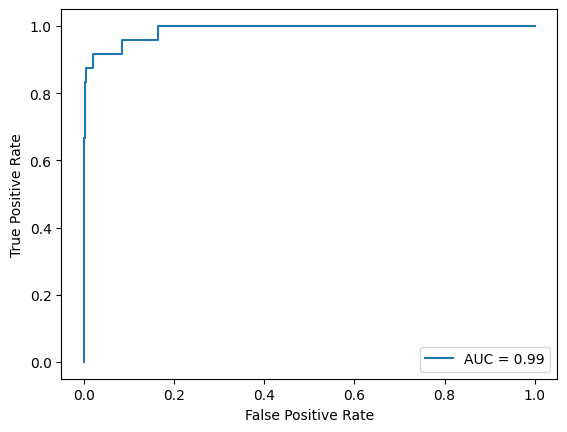

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

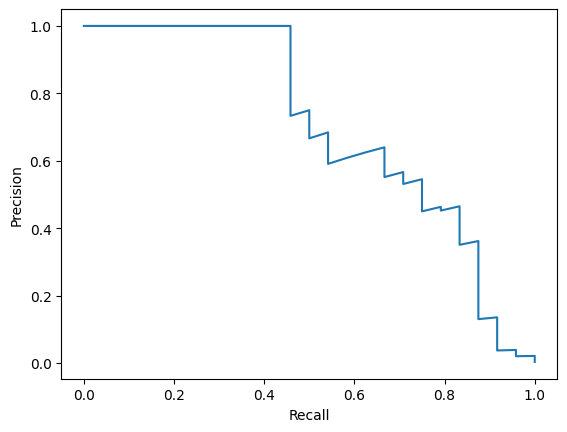

In [7]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

The Precision-Recall curve is useful for imbalanced datasets because it focuses on the performance of the minority (positive) class.

In [8]:
from sklearn.metrics import log_loss

loss = log_loss(y_test, y_prob)

print("Log Loss:", loss)

Log Loss: 0.007744803885221454


In [9]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_test_imb = y_test.sample(frac=0.1, random_state=42)

y_prob_imb = model.predict_proba(X_test.loc[y_test_imb.index])[:,1]
y_pred_imb = model.predict(X_test.loc[y_test_imb.index])

print("Accuracy:", accuracy_score(y_test_imb, y_pred_imb))
print("AUC:", roc_auc_score(y_test_imb, y_prob_imb))
print("Log Loss:", log_loss(y_test_imb, y_prob_imb))

Accuracy: 0.9985185185185185
AUC: 0.9981371087928466
Log Loss: 0.007713101443993559
